# Machine Learning Assignment 2 — Credit Card Default Prediction

**Dataset:** [UCI Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)
**Task:** Binary classification — predict whether a client will default on their credit card payment next month.

This notebook performs:
1. Data loading and exploratory checks
2. Preprocessing / cleaning
3. Train/test split (80/20, stratified)
4. Training 5 classification models: Logistic Regression, Decision Tree, kNN, Naive Bayes, Random Forest (Ensemble)
5. Evaluation using Accuracy, AUC, Precision, Recall, F1, MCC
6. Saving trained models (`model/*.joblib`) and the test split (`test_data.csv`) used by the Streamlit app

In [ ]:
# Auto-install notebook dependencies (e.g. xlrd for .xls files on BITS Virtual Lab).
# Skips packages that are already available in the current Jupyter kernel.
import importlib
import subprocess
import sys

NOTEBOOK_PACKAGES = {
    "joblib": "joblib>=1.3",
    "matplotlib": "matplotlib>=3.7",
    "pandas": "pandas>=2.0",
    "seaborn": "seaborn>=0.12",
    "sklearn": "scikit-learn>=1.3",
    "xlrd": "xlrd>=2.0",
}

missing = []
for module, spec in NOTEBOOK_PACKAGES.items():
    try:
        importlib.import_module(module)
    except ImportError:
        missing.append(spec)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing],
    )
    print("Install complete.")
else:
    print("All notebook dependencies already installed.")


In [1]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_style("whitegrid")

RANDOM_STATE = 42
TARGET_COL = "default"

BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "model" else os.getcwd()
RAW_DATA_PATH = os.path.join(BASE_DIR, "data", "default_of_credit_card_clients.xls")
MODEL_DIR = os.path.join(BASE_DIR, "model")
TEST_DATA_PATH = os.path.join(BASE_DIR, "test_data.csv")

print("Base dir:", BASE_DIR)

Base dir: C:\Assignment-2\credit-default-ml


## 1. Load Data & Exploratory Checks

In [2]:
df_raw = pd.read_excel(RAW_DATA_PATH, header=1)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df_raw.info()
print("\nMissing values per column:\n", df_raw.isnull().sum().sum(), "total missing values")
print("\nTarget distribution:")
print(df_raw["default payment next month"].value_counts(normalize=True).rename("proportion"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

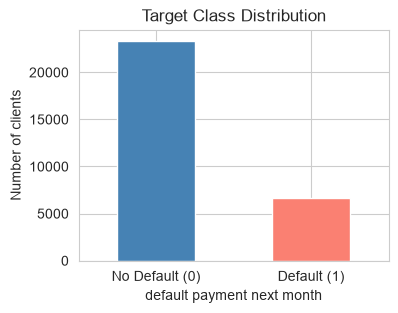

In [4]:
fig, ax = plt.subplots(figsize=(4, 3))
df_raw["default payment next month"].value_counts().plot.bar(ax=ax, color=["steelblue", "salmon"])
ax.set_xticklabels(["No Default (0)", "Default (1)"], rotation=0)
ax.set_title("Target Class Distribution")
ax.set_ylabel("Number of clients")
plt.show()

## 2. Preprocessing

- Drop the `ID` column (not predictive).
- Rename target to `default`.
- `EDUCATION` has undocumented codes `0`, `5`, `6` outside {1,2,3,4} — fold into category `4` ("others").
- `MARRIAGE` has an undocumented code `0` outside {1,2,3} — fold into category `3` ("others").

In [5]:
df = df_raw.drop(columns=["ID"]).rename(columns={"default payment next month": TARGET_COL})
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print(f"Features: {X.shape[1]} | Rows: {df.shape[0]}")
X.describe().T

Features: 23 | Rows: 30000


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


## 3. Train/Test Split (80/20, stratified)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 24000 | Test size: 6000


## 4. Build & Train 5 Classification Models

Each model is wrapped in a `scikit-learn` `Pipeline` (with `StandardScaler` for scale-sensitive models) so the exact same object can be saved and reused later for inference in the Streamlit app.

In [7]:
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("clf", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)),
    ]),
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15)),
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB()),
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=150, max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE
        )),
    ]),
}


def compute_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }


os.makedirs(MODEL_DIR, exist_ok=True)
results = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = compute_metrics(y_test, y_pred, y_proba)
    results[name] = metrics

    filename = name.lower().replace(" ", "_") + ".joblib"
    joblib.dump(pipeline, os.path.join(MODEL_DIR, filename))
    print(f"{name:22s} -> {metrics}")

Logistic Regression    -> {'Accuracy': 0.8083333333333333, 'AUC': 0.707924808472601, 'Precision': 0.6903225806451613, 'Recall': 0.24189902034664656, 'F1': 0.35825892857142855, 'MCC': 0.3276444060196226}


Decision Tree          -> {'Accuracy': 0.8156666666666667, 'AUC': 0.7431934741595443, 'Precision': 0.646746347941567, 'Recall': 0.36699321778447624, 'F1': 0.46826923076923077, 'MCC': 0.38845502108915797}


kNN                    -> {'Accuracy': 0.806, 'AUC': 0.7318519655717536, 'Precision': 0.6146272855133614, 'Recall': 0.32931424265259984, 'F1': 0.42885181550539747, 'MCC': 0.3475899299481722}
Naive Bayes            -> {'Accuracy': 0.7518333333333334, 'AUC': 0.724839064090703, 'Precision': 0.45036764705882354, 'Recall': 0.5538809344385832, 'F1': 0.4967894558972626, 'MCC': 0.3375616738757132}


Random Forest          -> {'Accuracy': 0.817, 'AUC': 0.7728192436435576, 'Precision': 0.6666666666666666, 'Recall': 0.34513941220798794, 'F1': 0.4548162859980139, 'MCC': 0.38598823490918677}


## 5. Evaluation — Comparison Table & Chart

In [8]:
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = "ML Model Name"

results_df.to_csv(os.path.join(MODEL_DIR, "metrics_comparison.csv"))
with open(os.path.join(MODEL_DIR, "metrics_comparison.json"), "w") as f:
    json.dump(results, f, indent=2)

results_df.style.highlight_max(axis=0, color="lightgreen")

,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.808300,0.707900,0.690300,0.241900,0.358300,0.327600
Decision Tree,0.815700,0.743200,0.646700,0.367000,0.468300,0.388500
kNN,0.806000,0.731900,0.614600,0.329300,0.428900,0.347600
Naive Bayes,0.751800,0.724800,0.450400,0.553900,0.496800,0.337600
Random Forest,0.817000,0.772800,0.666700,0.345100,0.454800,0.386000


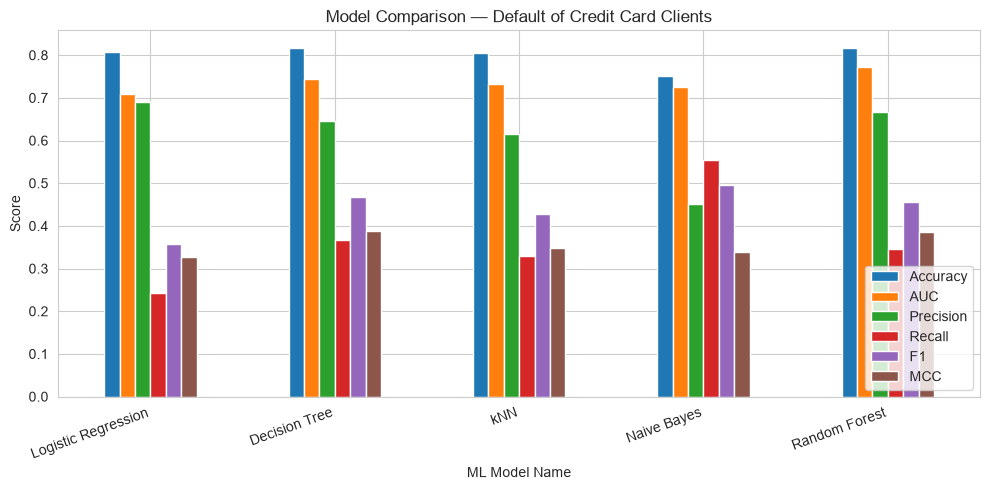

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot.bar(ax=ax)
ax.set_title("Model Comparison — Default of Credit Card Clients")
ax.set_ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Save Test Split for Submission & Streamlit App

The held-out 20% test split (features + true `default` label) is saved as `test_data.csv` at the project root. This is the file uploaded into the Streamlit app for live evaluation, and is included in the GitHub repository as required by the assignment.

In [10]:
test_df = X_test.copy()
test_df[TARGET_COL] = y_test.values
test_df.to_csv(TEST_DATA_PATH, index=False)
print(f"Saved test data -> {TEST_DATA_PATH} ({test_df.shape[0]} rows)")

Saved test data -> C:\Assignment-2\credit-default-ml\test_data.csv (6000 rows)
